---
title: "Gaussian plume — forward simulation and prior predictive"
---

# Forward simulation of a steady-state Gaussian plume

This notebook exercises the **forward model** in `plume_simulation.gauss_plume`: a steady-state Gaussian plume with Briggs-McElroy-Pooler dispersion coefficients, ground reflection, and wind-frame rotation. We'll render a few diagnostic views (horizontal column, vertical centerline slice, crosswind Gaussian profile), sweep over the six Pasquill-Gifford stability classes to see how dispersion scales, and finish by running the NumPyro model in **prior-predictive** mode to visualise the range of plumes implied by our emission-rate prior.

The fit-and-infer companion notebooks (02, 03) pick up from here: `02_emission_rate_parameter_estimation` inverts a downwind transect to recover Q, and `03_plume_state_estimation` treats Q as a time-varying latent state recovered from a sequence of observations.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive
from plume_simulation.gauss_plume import (
    BRIGGS_DISPERSION_PARAMS,
    STABILITY_CLASSES,
    gaussian_plume_model,
    plume_concentration,
    simulate_plume,
)

numpyro.set_host_device_count(1)
rng = np.random.default_rng(0)

## 1. Run a single forward simulation

Set up a canonical scenario: a ground-level leak of 0.1 kg/s from a 2 m stack, with a 5 m/s westerly wind (meteorological convention: `wind_direction = 270°` means wind *from* the west). Neutral stability (class D) is a good default for a daylight scenario with moderate wind.

In [2]:
ds = simulate_plume(
    emission_rate=0.1,
    source_location=(0.0, 0.0, 2.0),
    wind_speed=5.0,
    wind_direction=270.0,  # wind FROM the west
    stability_class="D",
    domain_x=(-50.0, 1200.0, 251),
    domain_y=(-180.0, 180.0, 181),
    domain_z=(0.0, 80.0, 21),
    background_conc=0.0,
)

print(ds)
print(f"\nPeak concentration:        {float(ds['concentration'].max()):.3e} kg/m^3")
print(f"Peak column concentration: {float(ds['column_concentration'].max()):.3e} kg/m^2")

<xarray.Dataset> Size: 4MB
Dimensions:               (x: 251, y: 181, z: 21)
Coordinates:
  * x                     (x) float64 2kB -50.0 -45.0 ... 1.195e+03 1.2e+03
  * y                     (y) float64 1kB -180.0 -178.0 -176.0 ... 178.0 180.0
  * z                     (z) float64 168B 0.0 4.0 8.0 12.0 ... 72.0 76.0 80.0
Data variables:
    concentration         (x, y, z) float32 4MB 0.0 0.0 ... 4.797e-08 4.055e-08
    column_concentration  (x, y) float32 182kB 0.0 0.0 ... 1.257e-05 1.204e-05
Attributes: (12/14)
    title:                     Steady-state Gaussian plume (JAX)
    emission_rate:             0.1
    emission_rate_units:       kg/s
    source_x:                  0.0
    source_y:                  0.0
    source_z:                  2.0
    ...                        ...
    wind_direction:            270.0
    wind_direction_units:      degrees from North (meteorological)
    wind_u:                    5.0
    wind_v:                    9.184850993605148e-16
    stability

## 2. Horizontal column view

Summing the concentration along z gives the column density the satellite would retrieve. The plume is a characteristic fan: narrow near the source, broadening with downwind distance as σ_y(x) grows.

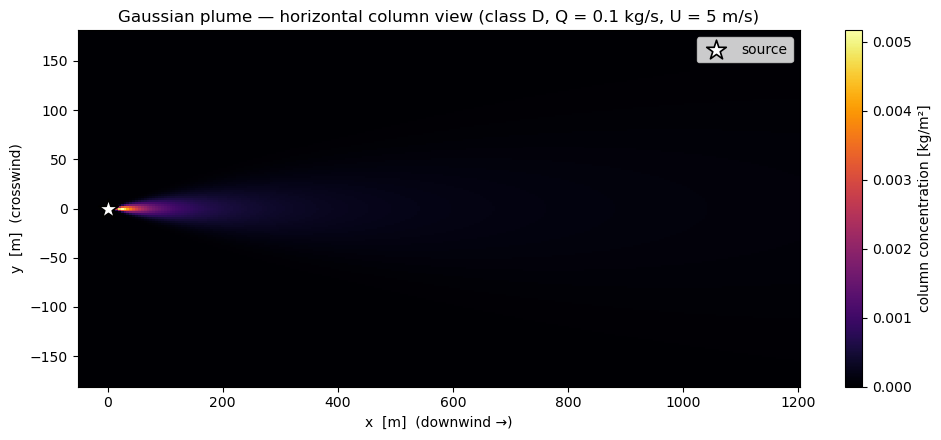

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.pcolormesh(
    ds["x"].values,
    ds["y"].values,
    ds["column_concentration"].T.values,
    cmap="inferno",
    shading="auto",
)
plt.colorbar(im, ax=ax, label="column concentration [kg/m²]")
ax.scatter([0.0], [0.0], marker="*", s=220, color="white", edgecolor="black",
           linewidth=1.2, zorder=5, label="source")
ax.set_xlabel("x  [m]  (downwind →)")
ax.set_ylabel("y  [m]  (crosswind)")
ax.set_title("Gaussian plume — horizontal column view (class D, Q = 0.1 kg/s, U = 5 m/s)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Vertical centerline slice and crosswind profile

A vertical slice along the plume centerline (y = 0) shows the **ground-reflected** vertical Gaussian — the concentration spreads upward from the stack and is reflected at z = 0, keeping all the mass in the boundary layer. The crosswind profile at a downwind distance of 500 m is a Gaussian in y, whose width is σ_y(500 m).

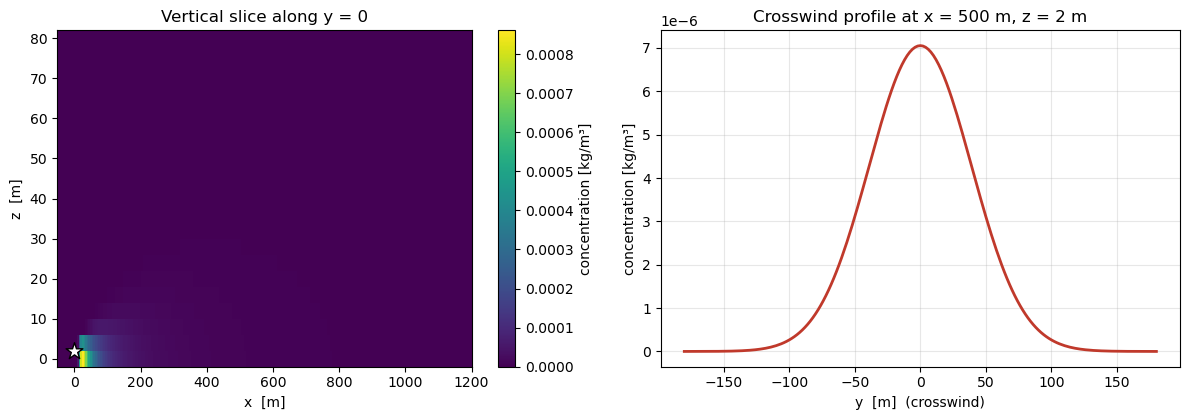

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

# Vertical centerline slice.
centerline = ds["concentration"].sel(y=0.0, method="nearest").T
im1 = ax1.pcolormesh(
    ds["x"].values, ds["z"].values, centerline.values,
    cmap="viridis", shading="auto",
)
plt.colorbar(im1, ax=ax1, label="concentration [kg/m³]")
ax1.scatter([0.0], [2.0], marker="*", s=160, color="white",
            edgecolor="black", linewidth=1.0, zorder=5)
ax1.set_xlabel("x  [m]")
ax1.set_ylabel("z  [m]")
ax1.set_title("Vertical slice along y = 0")

# Crosswind Gaussian profile at x = 500 m, z = 2 m.
cross = ds["concentration"].sel(x=500.0, z=2.0, method="nearest").values
ax2.plot(ds["y"].values, cross, color="#c0392b", linewidth=2.0)
ax2.set_xlabel("y  [m]  (crosswind)")
ax2.set_ylabel("concentration [kg/m³]")
ax2.set_title("Crosswind profile at x = 500 m, z = 2 m")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Stability-class sweep

The six Pasquill-Gifford classes span from **A (very unstable, strong daytime convection)** to **F (very stable, clear calm nights)**. Unstable classes disperse pollutants aggressively, spreading the plume quickly and lowering peak concentration; stable classes produce long, thin plumes with high peak near the source. Below we plot the centerline (y = 0, z = 0) concentration as a function of downwind distance for all six classes.

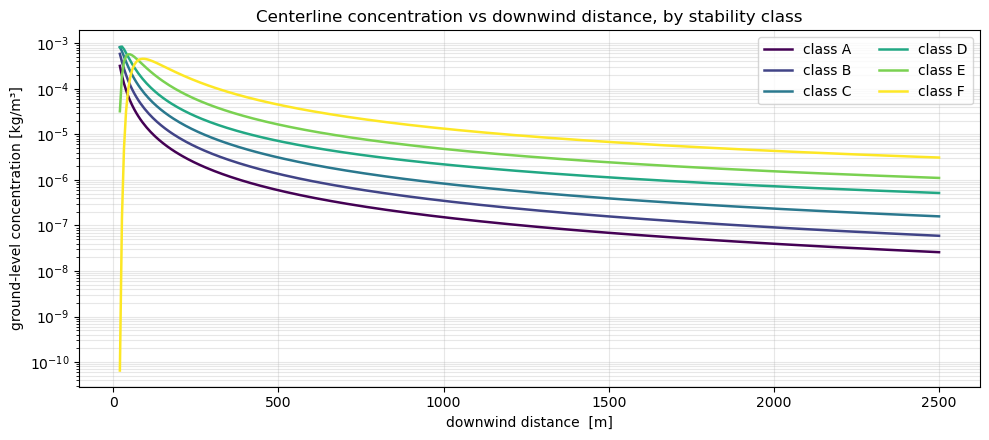

In [5]:
x_line = jnp.linspace(20.0, 2500.0, 400)
y_line = jnp.zeros_like(x_line)
z_line = jnp.zeros_like(x_line)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(STABILITY_CLASSES)))
for stab, color in zip(STABILITY_CLASSES, colors, strict=True):
    conc = plume_concentration(
        x_line, y_line, z_line,
        0.0, 0.0, 2.0,   # source
        5.0, 0.0,        # wind components (westerly at 5 m/s)
        0.1,             # emission rate
        BRIGGS_DISPERSION_PARAMS[stab],
    )
    ax.plot(np.asarray(x_line), np.asarray(conc), label=f"class {stab}",
            color=color, linewidth=1.8)

ax.set_xlabel("downwind distance  [m]")
ax.set_ylabel("ground-level concentration [kg/m³]")
ax.set_yscale("log")
ax.set_title("Centerline concentration vs downwind distance, by stability class")
ax.grid(alpha=0.3, which="both")
ax.legend(ncols=2, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Prior-predictive check with NumPyro

The `gaussian_plume_model` defined in `plume_simulation.gauss_plume.inference` wraps the forward model with a **LogNormal emission-rate prior** and a **HalfNormal background prior**. Running the model forward with `observations=None` samples predicted concentrations for each prior draw; this is a **prior-predictive check**, a useful sanity test that our priors are neither far too loose nor too tight for the scenario.

In [6]:
x_obs_np = np.linspace(200.0, 2000.0, 19)
y_obs_np = np.zeros_like(x_obs_np)
z_obs_np = np.ones_like(x_obs_np)

receptor_coords = (jnp.asarray(x_obs_np), jnp.asarray(y_obs_np), jnp.asarray(z_obs_np))

predictive = Predictive(gaussian_plume_model, num_samples=200)
samples = predictive(
    jax.random.PRNGKey(0),
    observations=None,
    receptor_coords=receptor_coords,
    source_location=(0.0, 0.0, 2.0),
    wind_u=5.0,
    wind_v=0.0,
    stability_class="D",
    prior_emission_rate_mean=0.1,
    prior_emission_rate_std=0.05,
    infer_stability=False,
)

prior_Q = np.asarray(samples["emission_rate"])
prior_obs = np.asarray(samples["obs"])   # shape (200, 19)

Below we plot:
1. The marginal prior over the emission rate Q (LogNormal centred on 0.1 kg/s).
2. The induced prior over ground-level concentrations along the transect, shown as the 5–95 % envelope and the median.

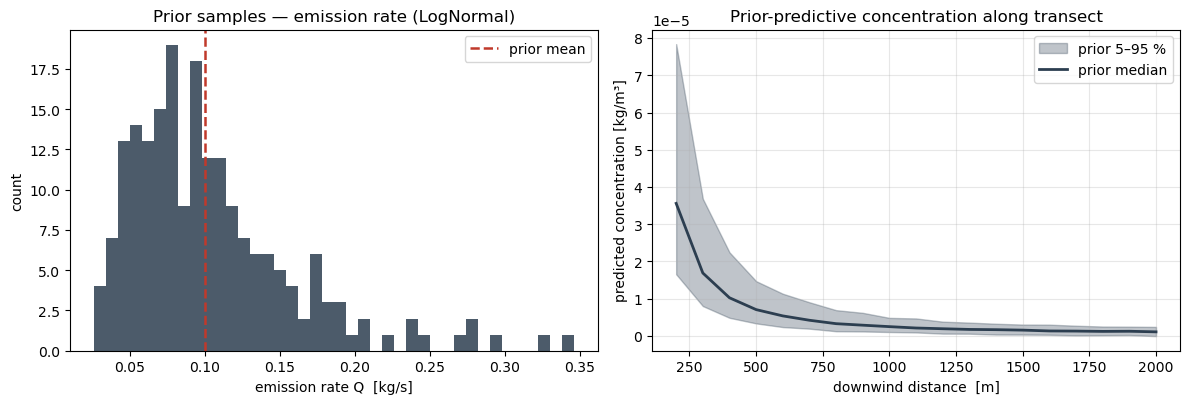

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

ax1.hist(prior_Q, bins=40, color="#2c3e50", alpha=0.85)
ax1.axvline(0.1, color="#c0392b", linestyle="--", linewidth=1.8, label="prior mean")
ax1.set_xlabel("emission rate Q  [kg/s]")
ax1.set_ylabel("count")
ax1.set_title("Prior samples — emission rate (LogNormal)")
ax1.legend()

p05 = np.percentile(prior_obs, 5, axis=0)
p50 = np.percentile(prior_obs, 50, axis=0)
p95 = np.percentile(prior_obs, 95, axis=0)
ax2.fill_between(x_obs_np, p05, p95, alpha=0.3, color="#2c3e50", label="prior 5–95 %")
ax2.plot(x_obs_np, p50, color="#2c3e50", linewidth=2.0, label="prior median")
ax2.set_xlabel("downwind distance  [m]")
ax2.set_ylabel("predicted concentration [kg/m³]")
ax2.set_title("Prior-predictive concentration along transect")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Summary

We have a fully differentiable, JIT-compiled forward model for a steady-state Gaussian plume, wrapped as an `xarray.Dataset` for diagnostic plotting and as a NumPyro-compatible function for Bayesian workflows. In the next notebook we **invert** this model — given a set of downwind concentrations, recover the emission rate Q. The one after that treats Q as a **time-varying state** in a random-walk state-space model.